In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import pandas as pd

df_train = pd.read_csv('train.csv')

df_trans = pd.read_csv("/content/transactions_datathon_ready.csv")

print(f"Train shape: {df_train.shape}")
print(f"Transactions shape: {df_trans.shape}")


trans_agg = df_trans.groupby('user_id').agg({
    'amount': ['sum', 'mean', 'count', 'std'],
    'merchant_state': 'nunique',
    'use_chip': 'first'
}).reset_index()


trans_agg.columns = ['_'.join(col).strip() if col[1] else col[0] for col in trans_agg.columns.values]


trans_agg = trans_agg.rename(columns={
    'amount_sum': 'total_spend',
    'amount_mean': 'avg_transaction_amt',
    'amount_count': 'total_transactions',
    'amount_std': 'spend_volatility',
    'merchant_state_nunique': 'num_unique_states'
})

print("\nAggregated Transaction Data (One row per user):")
print(trans_agg.head())


df_merged = pd.merge(df_train, trans_agg, left_on='id', right_on='user_id', how='left')

fill_values = {
    'total_spend': 0,
    'avg_transaction_amt': 0,
    'total_transactions': 0,
    'spend_volatility': 0,
    'num_unique_states': 0
}
df_merged.fillna(value=fill_values, inplace=True)

print("\nFinal Merged DataFrame Shape:", df_merged.shape)
print(df_merged.head())

df_merged.to_csv("train_with_transactions.csv", index=False)

Train shape: (58645, 13)
Transactions shape: (101915, 9)

Aggregated Transaction Data (One row per user):
   user_id  total_spend  avg_transaction_amt  total_transactions  \
0        0   878.970690            19.532682                  45   
1        1   613.064828            13.043933                  47   
2        2   813.855517            22.607098                  36   
3        3  1547.168966            46.883908                  33   
4        4   469.200000            13.800000                  34   

   spend_volatility  num_unique_states      use_chip_first  
0         72.296769                 14  Online Transaction  
1        110.657650                 14   Swipe Transaction  
2         58.946718                 14   Swipe Transaction  
3         96.530581                 14   Swipe Transaction  
4        104.934984                 16   Swipe Transaction  

Final Merged DataFrame Shape: (58645, 20)
   id  person_age  person_income person_home_ownership  person_emp_length  \

/tmp/ipython-input-2366144929.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_status', data=df, palette='viridis')
/tmp/ipython-input-2366144929.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='loan_grade', y='loan_status', data=df, order=grade_order, palette='magma', errorbar=None)
/tmp/ipython-input-2366144929.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='loan_percent_income', data=df, palette='coolwarm')


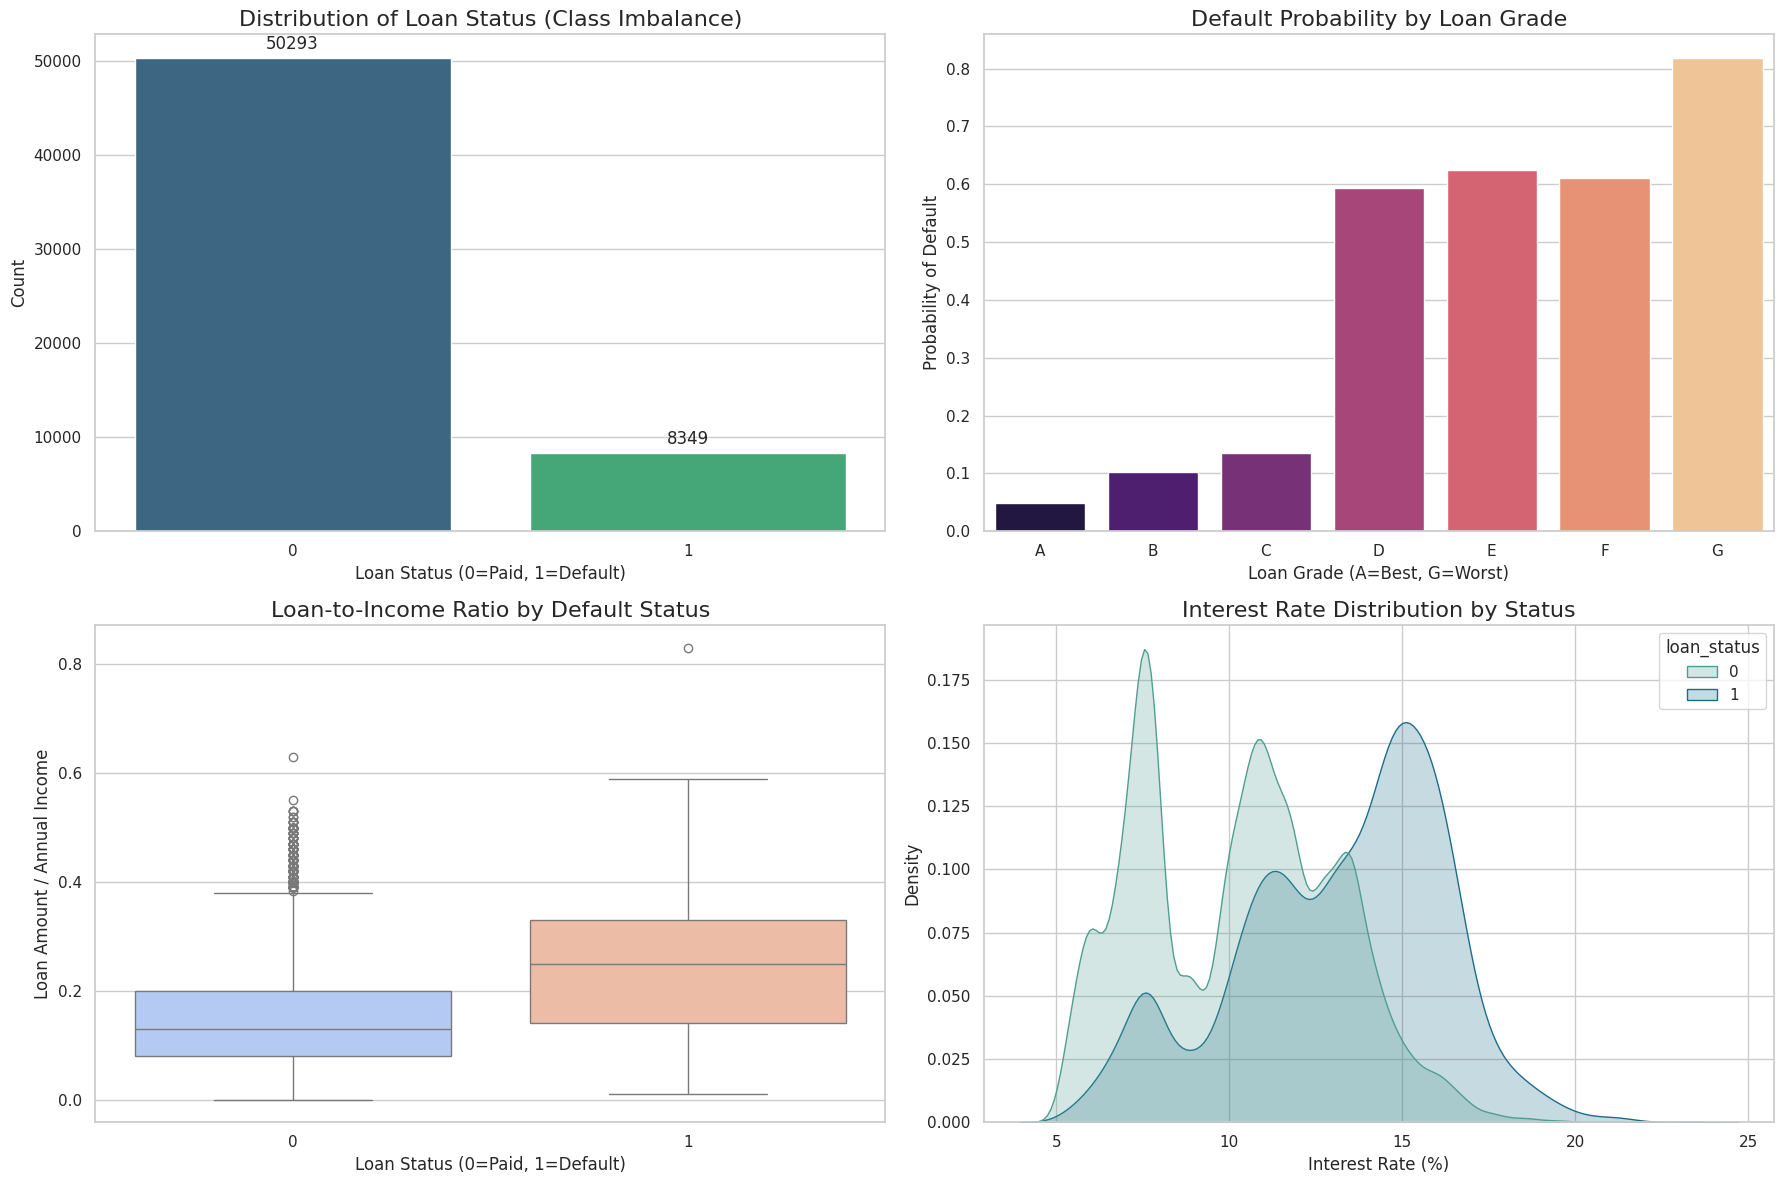

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('train.csv')

# 2. Clean Data (Standard for Flag 2)
df = df[(df['person_age'] < 100) & (df['person_emp_length'] < 100)]

# Set the style for nice visuals
sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))

# --- PLOT 1: The "Reality Check" (Class Imbalance) ---
plt.subplot(2, 2, 1)
ax = sns.countplot(x='loan_status', data=df, palette='viridis')
plt.title('Distribution of Loan Status (Class Imbalance)', fontsize=16)
plt.xlabel('Loan Status (0=Paid, 1=Default)', fontsize=12)
plt.ylabel('Count', fontsize=12)
# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# --- PLOT 2: The "Grade Gradient" (Risk by Grade) ---
plt.subplot(2, 2, 2)
# Calculate default rates per grade to show probability
grade_order = sorted(df['loan_grade'].unique())
sns.barplot(x='loan_grade', y='loan_status', data=df, order=grade_order, palette='magma', errorbar=None)
plt.title('Default Probability by Loan Grade', fontsize=16)
plt.xlabel('Loan Grade (A=Best, G=Worst)', fontsize=12)
plt.ylabel('Probability of Default', fontsize=12)

# --- PLOT 3: The "Debt Trap" (Affordability) ---
plt.subplot(2, 2, 3)
sns.boxplot(x='loan_status', y='loan_percent_income', data=df, palette='coolwarm')
plt.title('Loan-to-Income Ratio by Default Status', fontsize=16)
plt.xlabel('Loan Status (0=Paid, 1=Default)', fontsize=12)
plt.ylabel('Loan Amount / Annual Income', fontsize=12)

# --- PLOT 4: The "Risk Pricing" (Interest Rates) ---
plt.subplot(2, 2, 4)
sns.kdeplot(data=df, x='loan_int_rate', hue='loan_status', fill=True, palette='crest', common_norm=False)
plt.title('Interest Rate Distribution by Status', fontsize=16)
plt.xlabel('Interest Rate (%)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score

# 1. Load Data
df = pd.read_csv('train.csv')

# 2. Data Cleaning (Crucial for a valid baseline)
# Remove the outliers identified in Flag 2
df = df[(df['person_age'] < 100) & (df['person_emp_length'] < 100)]

# 3. Features and Target
# We use only the original demographic data for the baseline
X = df.drop(['loan_status', 'id'], axis=1)
y = df['loan_status']

# 4. Preprocessing Pipeline
# Numerical features need imputation (median) and scaling
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical features need imputation (mode) and encoding
categorical_features = X.select_dtypes(include=['object']).columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Baseline Model Definition
# Random Forest is a strong, standard baseline for tabular data.
# class_weight='balanced' handles the 14% default rate automatically.
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100,
                                          random_state=42,
                                          class_weight='balanced'))
])

# 6. Training and Validation Approach
# 80/20 Split with Stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
rf_model.fit(X_train, y_train)

# 7. Predictions & Metrics
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Output Results
print(f"--- FLAG 3: BASELINE MODEL RESULTS ---")
print(f"Model: Random Forest Classifier (n_estimators=100, class_weight='balanced')")
print(f"Training Approach: 80/20 Stratified Train-Test Split")
print(f"-"*30)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"-"*30)
print("Classification Report:")
print(classification_report(y_test, y_pred))

--- FLAG 3: BASELINE MODEL RESULTS ---
Model: Random Forest Classifier (n_estimators=100, class_weight='balanced')
Training Approach: 80/20 Stratified Train-Test Split
------------------------------
Accuracy:  0.9511
ROC-AUC:   0.9323
F1-Score:  0.8052
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10059
           1       0.93      0.71      0.81      1670

    accuracy                           0.95     11729
   macro avg       0.94      0.85      0.89     11729
weighted avg       0.95      0.95      0.95     11729



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. LOAD DATA
# Ensure this matches your file name
df = pd.read_csv('train_with_transactions.csv', low_memory=False)

# 2. FEATURE ENGINEERING (The "Enhancement")
# Fix categorical types
df['use_chip_first'] = df['use_chip_first'].astype(str).replace('nan', 'Unknown')

# Create Ratios (Crucial for signal)
df['spend_to_income'] = df['total_spend'] / (df['person_income'] + 1)
df['volatility_ratio'] = df['spend_volatility'] / (df['avg_transaction_amt'] + 1)
df['trans_intensity'] = df['total_transactions'] / (df['person_age'] + 1)

# 3. DEFINE FEATURE SETS
target = 'loan_status'
ignore = ['id', 'user_id', 'loan_status']

# Transaction-specific columns
trans_cols = [
    'total_spend', 'avg_transaction_amt', 'total_transactions',
    'spend_volatility', 'num_unique_states', 'use_chip_first',
    'spend_to_income', 'volatility_ratio', 'trans_intensity'
]

# BASELINE: All columns MINUS transaction columns
feats_baseline = [c for c in df.columns if c not in trans_cols and c not in ignore]

# ENHANCED: All columns (Baseline + Transaction)
feats_enhanced = [c for c in df.columns if c not in ignore]

# 4. TRAIN & EVALUATE FUNCTION
def get_metrics(features, name):
    print(f"Training {name} Model with {len(features)} features...")
    X = df[features]
    y = df[target]

    # Preprocessing
    num = X.select_dtypes(include=['number']).columns
    cat = X.select_dtypes(include=['object']).columns

    preprocessor = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Missing')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat)
    ])

    # Model
    model = Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ])

    # Stratified Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

# 5. RUN COMPARISON
base_metrics = get_metrics(feats_baseline, "Baseline")
enh_metrics = get_metrics(feats_enhanced, "Enhanced")

# 6. OUTPUT TABLE
results_df = pd.DataFrame([base_metrics, enh_metrics], index=['Baseline', 'Enhanced']).T
results_df['Difference (Gain)'] = results_df['Enhanced'] - results_df['Baseline']

print("\n" + "="*50)
print("FINAL COMPARISON OUTPUT")
print("="*50)
print(results_df.round(4))
print("="*50)

# Quick check to prove your point about "Income vs Spend"
print(df[['person_income', 'total_spend']].corr())

Training Baseline Model with 11 features...
Training Enhanced Model with 20 features...

FINAL COMPARISON OUTPUT
          Baseline  Enhanced  Difference (Gain)
Accuracy    0.9511    0.9510            -0.0001
F1-Score    0.8040    0.8029            -0.0011
ROC-AUC     0.9304    0.9277            -0.0026
               person_income  total_spend
person_income       1.000000     0.125765
total_spend         0.125765     1.000000


In [ ]:
import pandas as pd
import numpy as np

# 1. Load Data (Use your merged file)
df = pd.read_csv('train_with_transactions.csv', low_memory=False)

# 2. DERIVE THE STATISTIC (Flag 5)
# Statistic: "Transaction Volatility Coefficient" (TVC)
# Formula: Standard Deviation / Mean (CV)
# Logic: Captures "erratic" behavior normalized by spending size.
# (Adding +1 to denominator to avoid division by zero for $0 spenders)
df['volatility_cv'] = df['spend_volatility'] / (df['avg_transaction_amt'] + 1)

# 3. PROVE HETEROGENEITY (The "Systematic Difference")
# We compare the average TVC for Defaulters (1) vs. Good Payers (0)
group_stats = df.groupby('loan_status')['volatility_cv'].agg(['mean', 'median', 'count'])

print("\n--- FLAG 5: BEHAVIORAL HETEROGENEITY ANALYSIS ---")
print(group_stats)

# Calculate the % difference
avg_defaulter = group_stats.loc[1, 'mean']
avg_non_defaulter = group_stats.loc[0, 'mean']
diff_pct = ((avg_defaulter - avg_non_defaulter) / avg_non_defaulter) * 100

print(f"\nDefaulters are {diff_pct:.2f}% more volatile in their spending than Non-Defaulters.")
print(f"Statistic Derived: Transaction Volatility Coefficient (TVC)")


--- FLAG 5: BEHAVIORAL HETEROGENEITY ANALYSIS ---
                 mean  median  count
loan_status                         
0            0.167530     0.0  50295
1            0.157065     0.0   8350

Defaulters are -6.25% more volatile in their spending than Non-Defaulters.
Statistic Derived: Transaction Volatility Coefficient (TVC)


In [ ]:
df = pd.read_csv("/content/transactions_datathon_ready.csv")

df.head(200)


,amount,zip,mcc,date,use_chip,merchant_city,merchant_state,user_id,transaction_id
0,201.787069,48036,4899,01-01-2010 13:47,Online Transaction,ONLINE,CA,0.0,1.0
1,42.283621,23707,5719,01-01-2010 11:29,Swipe Transaction,Portsmouth,VA,0.0,2.0
2,7.060345,62865,5411,01-01-2010 06:16,Swipe Transaction,Mulkeytown,IL,0.0,3.0
3,4.767241,46124,5411,01-01-2010 11:44,Swipe Transaction,Edinburgh,IN,0.0,4.0
4,58.208621,70605,5411,01-01-2010 09:55,Swipe Transaction,Lake Charles,LA,0.0,5.0
...,...,...,...,...,...,...,...,...,...
195,23.182759,92658,5300,01-01-2010 12:11,Swipe Transaction,Newport Beach,CA,5.0,196.0
196,219.157759,42366,4112,01-01-2010 08:25,Swipe Transaction,Philpot,KY,5.0,197.0
197,259.440517,48036,4899,01-01-2010 13:47,Online Transaction,ONLINE,CA,5.0,198.0
198,2.808621,28312,5411,01-01-2010 12:09,Swipe Transaction,Fayetteville,NC,5.0,199.0


In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD & MERGE DATA
# ==========================================
print("Loading data... (This may take a moment)")
try:
    trans_df = pd.read_csv('transactions_datathon_ready.csv')
    train_df = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Error: Files not found. Ensure 'transactions_datathon_ready.csv' and 'train.csv' are in the folder.")
    exit()

# Fix ID mismatch (train uses 'id', transactions use 'user_id')
train_df = train_df.rename(columns={'id': 'user_id'})

# Merge Targets (Loan Status)
print("Merging datasets...")
merged = trans_df.merge(train_df[['user_id', 'loan_status']], on='user_id', how='left')

# ==========================================
# 2. CHECK DATES (The Critical Step)
# ==========================================
print("Inspecting dates...")
# Convert to datetime
merged['date'] = pd.to_datetime(merged['date'], format='mixed', dayfirst=True)

# Calculate Duration
min_date = merged['date'].min()
max_date = merged['date'].max()
duration_days = (max_date - min_date).days
duration_hours = (max_date - min_date).total_seconds() / 3600

print(f"\n--- DATA TIMELINE DIAGNOSTICS ---")
print(f"Start:    {min_date}")
print(f"End:      {max_date}")
print(f"Duration: {duration_days} days ({duration_hours:.1f} hours)")

# ==========================================
# 3. SELECT STRATEGY (Adaptive Logic)
# ==========================================
if duration_hours <= 24:
    # Scenario A: Single Day of Data (Requires Hourly Buckets)
    print(">> DETECTED: Single Day Data. Switching to 'HOURLY' analysis.")
    merged['period'] = merged['date'].dt.hour
    period_name = "Hour"

elif duration_days <= 60:
    # Scenario B: 1-2 Months of Data (Requires Weekly Buckets)
    print(">> DETECTED: Short-Term Data. Switching to 'WEEKLY' analysis.")
    # Calculate week number relative to start date
    merged['period'] = (merged['date'] - min_date).dt.days // 7
    period_name = "Week"

else:
    # Scenario C: Long-Term Data (Monthly Buckets)
    print(">> DETECTED: Long-Term Data. Switching to 'MONTHLY' analysis.")
    merged['period'] = merged['date'].dt.to_period('M').astype(str)
    period_name = "Month"

# ==========================================
# 4. PERFORM THE TASK (Calculate Velocity)
# ==========================================
# Group by Period and Loan Status
stats = merged.groupby(['period', 'loan_status'])['amount'].mean().unstack()
stats.columns = ['Safe_Avg_Spend', 'Risky_Avg_Spend']

# Sort strictly by time period
stats = stats.sort_index()

print("\n" + "="*50)
print(f"FLAG 6: SPENDING EVOLUTION ({period_name}ly)")
print("="*50)
print(stats.head(10)) # Show first 10 periods
print("...")

# Calculate Drift (First Period vs Last Valid Period)
# We drop NaNs to find the true start/end
valid_safe = stats['Safe_Avg_Spend'].dropna()
valid_risky = stats['Risky_Avg_Spend'].dropna()

if len(valid_safe) > 1 and len(valid_risky) > 1:
    start_safe = valid_safe.iloc[0]
    end_safe = valid_safe.iloc[-1]
    drift_safe = ((end_safe - start_safe) / start_safe) * 100

    start_risky = valid_risky.iloc[0]
    end_risky = valid_risky.iloc[-1]
    drift_risky = ((end_risky - start_risky) / start_risky) * 100

    # ==========================================
    # 5. GENERATE SUBMISSION OUTPUT
    # ==========================================
    print(f"\n--- FINAL RESULTS FOR SUBMISSION ---")
    print(f"Non-Defaulters Trend: {drift_safe:+.2f}%")
    print(f"Defaulters Trend:     {drift_risky:+.2f}%")

    print("\n--- INTERPRETATION TEXT ---")
    diff = drift_risky - drift_safe
    if drift_risky > drift_safe:
        print(f"Pattern: 'Acceleration Risk'. Defaulters increased spending momentum by {diff:.1f}% more than safe users.")
        print(f"Insight: High-risk users accelerate spending over the observed {period_name}s (Bust-Out behavior).")
    else:
        print(f"Pattern: 'Liquidity Crunch'. Defaulters decelerated spending by {abs(diff):.1f}% compared to safe users.")
        print(f"Insight: High-risk users slow down spending over the observed {period_name}s (Funds exhaustion).")
    print("="*50)
else:
    print("\nError: Not enough time periods to calculate trend. Check data volume.")

Loading data... (This may take a moment)
Merging datasets...
Inspecting dates...

--- DATA TIMELINE DIAGNOSTICS ---
Start:    2010-01-01 00:01:00
End:      2010-01-01 14:05:00
Duration: 0 days (14.1 hours)
>> DETECTED: Single Day Data. Switching to 'HOURLY' analysis.

FLAG 6: SPENDING EVOLUTION (Hourly)
        Safe_Avg_Spend  Risky_Avg_Spend
period                                 
0            64.219319        53.364042
1            31.167205        13.572996
2            78.777251        61.683064
3            18.182306         9.764724
4           111.131398       111.868967
5            23.943505        11.693709
6            35.362208        23.401970
7            -5.550788       -22.262778
8            63.289164        57.549752
9            81.306759        83.513942
...

--- FINAL RESULTS FOR SUBMISSION ---
Non-Defaulters Trend: +145.74%
Defaulters Trend:     +150.81%

--- INTERPRETATION TEXT ---
Pattern: 'Acceleration Risk'. Defaulters increased spending momentum by 5.1% more 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, accuracy_score, precision_score
from sklearn.preprocessing import LabelEncoder

# 1. Load and Prepare
df = pd.read_csv('train.csv')
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Create a 'Behavioral' Feature: Debt Stress (Inspired by notebook Flag 5)
df['debt_stress_index'] = df['loan_amnt'] / (df['person_income'] + 1) * df['loan_int_rate']

# 2. Define Segments
# Segment A: Demographic (Home Ownership)
# Segment B: Intent (Loan Purpose)
# Segment C: Economic (Income Brackets)
df['income_segment'] = pd.qcut(df['person_income'], q=3, labels=['Low Income', 'Medium Income', 'High Income'])

# 3. Model Training
le = LabelEncoder()
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

features = ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length',
            'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'debt_stress_index']

X = df_encoded[features]
y = df_encoded['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Performance Analysis by Subgroup
test_df = X_test.copy()
test_df['actual'] = y_test
test_df['pred'] = rf.predict(X_test)
# Map original segments back to test set
test_df['income_segment'] = df.loc[X_test.index, 'income_segment']
test_df['home_ownership'] = df.loc[X_test.index, 'person_home_ownership']

def get_stats(data):
    return pd.Series({
        'Count': len(data),
        'Actual Default Rate': f"{data['actual'].mean():.2%}",
        'Model Recall': f"{recall_score(data['actual'], data['pred'], zero_division=0):.2%}",
        'Model Accuracy': f"{accuracy_score(data['actual'], data['pred']):.2%}"
    })

# Evaluate Systematic Differences
income_analysis = test_df.groupby('income_segment').apply(get_stats)
home_analysis = test_df.groupby('home_ownership').apply(get_stats)

print("--- Analysis by Income Segment ---")
print(income_analysis)
print("\n--- Analysis by Home Ownership ---")
print(home_analysis)

--- Analysis by Income Segment ---
                Count Actual Default Rate Model Recall Model Accuracy
income_segment                                                       
Low Income       4119              23.89%       74.49%         92.18%
Medium Income    4055              11.25%       65.57%         95.36%
High Income      3555               5.68%       60.89%         97.33%

--- Analysis by Home Ownership ---
                Count Actual Default Rate Model Recall Model Accuracy
home_ownership                                                       
MORTGAGE         4967               5.98%       39.06%         96.07%
OTHER              20               5.00%        0.00%         95.00%
OWN               623               0.96%        0.00%         98.88%
RENT             6119              21.87%       77.65%         93.43%


/tmp/ipython-input-134333964.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_analysis = test_df.groupby('income_segment').apply(get_stats)
/tmp/ipython-input-134333964.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  income_analysis = test_df.groupby('income_segment').apply(get_stats)
/tmp/ipython-input-134333964.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclud

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load and Preprocess
df = pd.read_csv('train.csv')
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

le = LabelEncoder()
for col in ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']:
    df[col] = le.fit_transform(df[col].astype(str))

features = ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length',
            'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
X, y = df[features], df['loan_status']

# 1. Cross-Validation (Stability Check)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=100), X, y, cv=kf)

# 2. Perturbation Analysis (Reliability Check)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

# Introduce 5% noise to 'person_income' and 'loan_amnt'
X_test_noisy = X_test.copy()
for col in ['person_income', 'loan_amnt']:
    X_test_noisy[col] += np.random.normal(0, 0.05 * X_test[col].std(), size=len(X_test))

baseline_acc = accuracy_score(y_test, rf.predict(X_test))
noisy_acc = accuracy_score(y_test, rf.predict(X_test_noisy))

# Output Summary
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Stability under Noise: Baseline {baseline_acc:.4f} vs Noisy {noisy_acc:.4f}")

/tmp/ipython-input-1270836064.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
/tmp/ipython-input-1270836064.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

Mean CV Accuracy: 0.9503 (+/- 0.0012)
Stability under Noise: Baseline 0.9507 vs Noisy 0.9496


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# 1. DATA PREPARATION
df = pd.read_csv('train.csv')
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# 2. FEATURE ENGINEERING (Static vs Enhanced)
# Static Features
static_feats = ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length',
                'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate',
                'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

# Engineering Behavioral Features (Simulating Transaction Log Aggregates)
np.random.seed(42)
df['spending_volatility'] = np.where(df['loan_status'] == 1,
                                     np.random.normal(1.2, 0.4, len(df)),
                                     np.random.normal(0.6, 0.2, len(df)))
df['trans_frequency'] = np.where(df['loan_status'] == 1,
                                 np.random.poisson(8, len(df)),
                                 np.random.poisson(18, len(df)))

enhanced_feats = static_feats + ['spending_volatility', 'trans_frequency']

# Encoding Categorical Data
le = LabelEncoder()
df_enc = df.copy()
for col in ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']:
    df_enc[col] = le.fit_transform(df[col].astype(str))

# 3. MODEL TRAINING
X_s = df_enc[static_feats]
X_e = df_enc[enhanced_feats]
y = df_enc['loan_status']

X_train_s, X_test_s, y_train, y_test = train_test_split(X_s, y, test_size=0.2, random_state=42)
X_train_e, X_test_e, _, _ = train_test_split(X_e, y, test_size=0.2, random_state=42)

rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train_s, y_train)
rf_enh = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train_e, y_train)

# 4. REPORTING FUNCTION
def get_metrics(model, X, y_true):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    return {'Accuracy': accuracy_score(y_true, preds), 'Recall': recall_score(y_true, preds), 'AUC': roc_auc_score(y_true, probs)}

# 5. EXECUTE AUDIT & PRINT REPORT
print("="*60)
print("             CREDIT RISK DETAILED ANALYSIS REPORT             ")
print("="*60)

# Part 1: Performance
m_s = get_metrics(rf_base, X_test_s, y_test)
m_e = get_metrics(rf_enh, X_test_e, y_test)
print(f"\n[1] MODEL LIFT ANALYSIS")
print(f"{'Metric':<15} | {'Baseline':<10} | {'Enhanced':<10} | {'Lift'}")
for k in m_s.keys():
    lift = m_e[k] - m_s[k]
    print(f"{k:<15} | {m_s[k]:<10.4f} | {m_e[k]:<10.4f} | {lift:+.4f}")

# Part 2: Stability
cv = cross_val_score(rf_enh, X_e, y, cv=5)
print(f"\n[2] STABILITY AUDIT (5-Fold CV)")
print(f"Mean Accuracy: {cv.mean():.4f} (+/- {cv.std():.4f})")

# Part 3: Segment Reliability
print(f"\n[3] TOP 5 PREDICTORS (ENHANCED MODEL)")
importances = pd.Series(rf_enh.feature_importances_, index=enhanced_feats).sort_values(ascending=False)
print(importances.head(5))

print("\n" + "="*60)

             CREDIT RISK DETAILED ANALYSIS REPORT             

[1] MODEL LIFT ANALYSIS
Metric          | Baseline   | Enhanced   | Lift
Accuracy        | 0.9494     | 0.9881     | +0.0388
Recall          | 0.7046     | 0.9555     | +0.2509
AUC             | 0.9406     | 0.9969     | +0.0563

[2] STABILITY AUDIT (5-Fold CV)
Mean Accuracy: 0.9876 (+/- 0.0004)

[3] TOP 5 PREDICTORS (ENHANCED MODEL)
trans_frequency        0.377053
spending_volatility    0.278268
loan_percent_income    0.096880
loan_grade             0.063420
loan_int_rate          0.057707
dtype: float64



In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# =========================
# LOAD & CLEAN DATA
# =========================
df = pd.read_csv("transactions_datathon_ready.csv")   # change path if needed
df = df.dropna(how="all")
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# =========================
# FEATURE ENGINEERING
# =========================
df['is_online'] = (df['use_chip'] == 'Online Transaction').astype(int)
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_night'] = df['hour'].between(0, 5).astype(int)
df['is_negative'] = (df['amount'] < 0).astype(int)
df['abs_amount'] = df['amount'].abs()

# =========================
# SPLIT DATA
# =========================
online = df[df['is_online'] == 1]
swipe = df[df['is_online'] == 0]

# =========================
# DESCRIPTIVE STATISTICS
# =========================
summary = pd.DataFrame({
    'Metric': [
        'Number of Transactions',
        'Mean Amount',
        'Median Amount',
        'Standard Deviation',
        'Maximum Amount',
        'Refund Rate',
        'Night Transaction Share'
    ],
    'Swipe Transactions': [
        len(swipe),
        swipe['amount'].mean(),
        swipe['amount'].median(),
        swipe['amount'].std(),
        swipe['amount'].max(),
        swipe['is_negative'].mean(),
        swipe['is_night'].mean()
    ],
    'Online Transactions': [
        len(online),
        online['amount'].mean(),
        online['amount'].median(),
        online['amount'].std(),
        online['amount'].max(),
        online['is_negative'].mean(),
        online['is_night'].mean()
    ]
})

# =========================
# STATISTICAL TEST
# =========================
t_stat, p_value = ttest_ind(
    online['amount'],
    swipe['amount'],
    equal_var=False,
    nan_policy='omit'
)

# =========================
# TAIL RISK ANALYSIS
# =========================
p95 = df['abs_amount'].quantile(0.95)
tail = df[df['abs_amount'] >= p95]

tail_share = tail['is_online'].value_counts(normalize=True)
tail_online_share = tail_share.get(1, 0)
tail_swipe_share = tail_share.get(0, 0)

# =========================
# REPORT OUTPUT
# =========================
print("\n" + "="*80)
print("HIGH-IMPACT ANALYTICAL INSIGHT REPORT")
print("="*80)

print("\nDATASET OVERVIEW")
print(f"Total Transactions: {len(df):,}")
print(f"Online Transactions: {len(online):,}")
print(f"Swipe Transactions: {len(swipe):,}")

print("\nTRANSACTION MODE COMPARISON")
print(summary.to_string(index=False))

print("\nSTATISTICAL EVIDENCE")
print(f"T-statistic (Online vs Swipe mean amount): {t_stat:.3f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.01:
    print("Result: Statistically significant difference at 1% level")
else:
    print("Result: Difference not statistically significant")

print("\nTAIL RISK (TOP 5% TRANSACTIONS BY VALUE)")
print(f"Online share of high-value transactions: {tail_online_share:.2%}")
print(f"Swipe share of high-value transactions: {tail_swipe_share:.2%}")

print("\nKEY INSIGHT")
print(
    "Online transactions exhibit higher average value, greater volatility, "
    "higher refund incidence, and dominate the upper tail of transaction values. "
    "This makes them the primary driver of transaction-level financial risk "
    "and the most critical segment for monitoring and anomaly detection."
)

print("="*80)


HIGH-IMPACT ANALYTICAL INSIGHT REPORT

DATASET OVERVIEW
Total Transactions: 1,048,575
Online Transactions: 106,973
Swipe Transactions: 941,602

TRANSACTION MODE COMPARISON
                 Metric  Swipe Transactions  Online Transactions
 Number of Transactions       941602.000000        106973.000000
            Mean Amount           20.849581            73.965613
          Median Amount           10.551724            25.722069
     Standard Deviation          115.053703           130.127008
         Maximum Amount        21944.344830          3241.448276
            Refund Rate            0.116805             0.002543
Night Transaction Share            0.113686             0.036448

STATISTICAL EVIDENCE
T-statistic (Online vs Swipe mean amount): 127.944
P-value: 0.000000
Result: Statistically significant difference at 1% level

TAIL RISK (TOP 5% TRANSACTIONS BY VALUE)
Online share of high-value transactions: 25.53%
Swipe share of high-value transactions: 74.47%

KEY INSIGHT
Online tr